# 로지스틱 회귀

## 럭키백의 확률
- 데이터 준비하기

In [5]:
import pandas as pd

fish = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hongong-ml/master/fish.csv')
fish.head()

# 품종/무게/길이/대각선/높이/폭 => 6가지 정보
# 첫줄을 자동으로 컬럼명으로 가져옴 : 기본
# 인덱스는 자동으로 가져오지 않는다

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [6]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [7]:
# 품종에서 유일한 값을 추출  ==> 7개 종류

print( pd.unique(fish['Species']) )

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str


In [8]:
# 데이터프레임에서 5개 열을 추출하여 넘파이로 변환하여 저장

# 입력 데이터 준비 : 5개 열의 숫자 데이터
fish_input = fish[ ['Weight','Length','Diagonal','Height','Width'] ].to_numpy()

In [9]:
# 넘파이 이므로 : 행과 열의 값만  // 인덱스, 열제목 없음

print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [10]:
# 타겟 데이터 준비 : 정답지 (품종)

fish_target = fish['Species'].to_numpy()
fish_target

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Roach', 'Roach', 'Roach', 'Roach', 'Roach', 'Roach', 'Roach',
       'Roach', 'Roach', 'Roach', 'Roach', 'Roach', 'Roach', 'Roach',
       'Roach', 'Roach', 'Roach', 'Roach', 'Roach', 'Roach', 'Whitefish',
       'Whitefish', 'Whitefish', 'Whitefish', 'Whitefish', 'Whitefish',
       'Parkki', 'Parkki', 'Parkki', 'Parkki', 'Parkki', 'Parkki',
       'Parkki', 'Parkki', 'Parkki', 'Parkki', 'Parkki', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perc

In [11]:
# 훈련데이터(입력, 타겟), 테스트데이터(입력, 타겟)로 나눔

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

In [12]:
# 표준화 전처리
# StandardScaler()
# -> 모든 피처들을 평균이 0, 분산이 1인 정규분포를 갖도록 만들어줌
# -> 즉, 표준화 해주는 방법

In [13]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

# 훈련세트 : fit, transform
ss.fit(train_input)
train_scaled = ss.transform(train_input)

# 테스트세트 : transform
test_scaled = ss.transform(test_input)

# 필요한 데이터는 모두 준비 되었다.

## k-최근접 이웃 분류기의 확률 예측

In [14]:
# 훈련 셋트로 훈련하고, 테스트 셋트로 점수 확인

from sklearn.neighbors import KNeighborsClassifier

# 최근접 이웃 갯수 3개  / 2,3,4,5 적용해서 스코어가 높은것 확인할 것
kn = KNeighborsClassifier(n_neighbors=3)

kn.fit(train_scaled, train_target)

print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [15]:
# 피쉬 데이터프레임에서 7가지 품종 :
# ['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']

# 이렇게 타깃데이터가 2개 이상이면 다중분류!
# 앞서는 1,0 : 이진분류
# 다중분류시 타킷을 숫자로 변경가능하나 사이킷런에서 문자열로 된 타킷값 사용가능

In [16]:
print(kn.classes_)

# 출력 정렬됨

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [17]:
# test_scaled

print(test_scaled[:5])


[[-0.88741352 -0.91804565 -1.03098914 -0.90464451 -0.80762518]
 [-1.06924656 -1.50842035 -1.54345461 -1.58849582 -1.93803151]
 [-0.54401367  0.35641402  0.30663259 -0.8135697  -0.65388895]
 [-0.34698097 -0.23396068 -0.22320459 -0.11905019 -0.12233464]
 [-0.68475132 -0.51509149 -0.58801052 -0.8998784  -0.50124996]]


In [18]:
# 테스트세트의 위 5개로 품종 예측

print(kn.predict(test_scaled[:5]))


['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [19]:
import numpy as np

# predict_proba 메소드: 클래스별 확률값 반환
proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [20]:
# 결과 설명
"""
 ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
------------------------------------------------------------------------------
 [  [0.     0.       1.      0.      0.      0.      0.    ]  => Perch
    [0.     0.       0.      0.      0.      1.      0.    ]  => Smelt
    [0.     0.       0.      1.      0.      0.      0.    ]  => Pike
    [0.     0.       0.6667  0.      0.3333  0.      0.    ]  => Perch or Roach
    [0.     0.       0.6667  0.      0.3333  0.      0.    ]] => Perch or Roach
"""

"\n ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']\n------------------------------------------------------------------------------\n [  [0.     0.       1.      0.      0.      0.      0.    ]  => Perch\n    [0.     0.       0.      0.      0.      1.      0.    ]  => Smelt\n    [0.     0.       0.      1.      0.      0.      0.    ]  => Pike\n    [0.     0.       0.6667  0.      0.3333  0.      0.    ]  => Perch or Roach\n    [0.     0.       0.6667  0.      0.3333  0.      0.    ]] => Perch or Roach\n"

In [21]:
# 네번째 샘플의 이웃 3개

distances, indexes = kn.kneighbors(test_scaled[3:4])  # 3 인덱스 모든컬럼 정보
print(train_target[indexes])

# 이웃 3개중에 Perch가 2개, Roach가 1개
# 따라서 Perch 확률 : 0.6667 // Roach 확률 : 0.3333

[['Roach' 'Perch' 'Perch']]


## 로지스틱 회귀
- 보통 회귀는 값을 예측하나, 로지스틱 회귀는 분류 모델이다

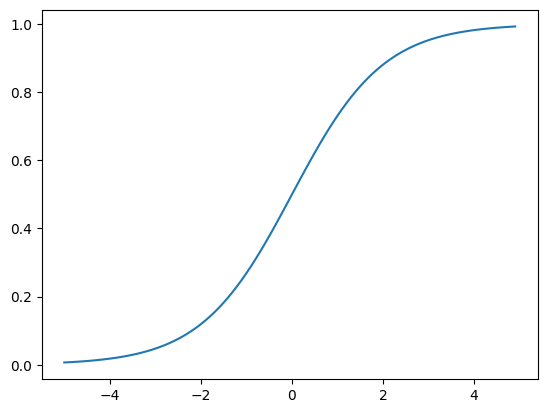

In [22]:
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)    # -5 ~ 5 전까지의 0.1 간격으로

phi = 1 / (1 + np.exp(-z))   # 시그모이드 함수

plt.plot(z, phi)
plt.show()

# 시그모이드 함수 : 어떤값이든 -> 0 ~ 1 사이로 변환
# 로지스틱 회귀 : 0.5 까지 음성클래스 , 0.5 이상 양성클래스  => 분류이므로...

In [23]:
z

array([-5.00000000e+00, -4.90000000e+00, -4.80000000e+00, -4.70000000e+00,
       -4.60000000e+00, -4.50000000e+00, -4.40000000e+00, -4.30000000e+00,
       -4.20000000e+00, -4.10000000e+00, -4.00000000e+00, -3.90000000e+00,
       -3.80000000e+00, -3.70000000e+00, -3.60000000e+00, -3.50000000e+00,
       -3.40000000e+00, -3.30000000e+00, -3.20000000e+00, -3.10000000e+00,
       -3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -1.77635684e-14,  1.00000000e-01,
        2.00000000e-01,  

### 로지스틱 회귀로 이진 분류 수행하기

In [24]:
# 블리언 인덱싱 예제
# 블리언 인덱싱 : 배열에서 True 것만 출력

char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print( char_arr[ [True, False, True, False, False] ] )

['A' 'C']


In [25]:
train_target

array(['Bream', 'Pike', 'Smelt', 'Perch', 'Parkki', 'Roach', 'Perch',
       'Bream', 'Perch', 'Perch', 'Perch', 'Bream', 'Perch', 'Parkki',
       'Perch', 'Bream', 'Smelt', 'Perch', 'Roach', 'Bream', 'Pike',
       'Bream', 'Pike', 'Perch', 'Parkki', 'Bream', 'Perch', 'Pike',
       'Bream', 'Perch', 'Parkki', 'Roach', 'Perch', 'Bream', 'Roach',
       'Perch', 'Bream', 'Bream', 'Perch', 'Perch', 'Roach', 'Pike',
       'Perch', 'Smelt', 'Pike', 'Roach', 'Perch', 'Parkki', 'Perch',
       'Bream', 'Perch', 'Smelt', 'Perch', 'Parkki', 'Smelt', 'Perch',
       'Perch', 'Roach', 'Bream', 'Perch', 'Perch', 'Roach', 'Roach',
       'Perch', 'Perch', 'Bream', 'Roach', 'Bream', 'Roach', 'Parkki',
       'Perch', 'Perch', 'Perch', 'Perch', 'Pike', 'Pike', 'Perch',
       'Bream', 'Perch', 'Bream', 'Whitefish', 'Pike', 'Bream', 'Bream',
       'Roach', 'Perch', 'Pike', 'Bream', 'Pike', 'Parkki', 'Roach',
       'Perch', 'Roach', 'Smelt', 'Whitefish', 'Roach', 'Perch', 'Bream',
       'Whitefi

In [26]:
# 이진분류 실습을 위해 2개 품종만 선택
# 훈련세트에서 Bream 또는 Smelt 만 True

bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')

bream_smelt_indexes

array([ True, False,  True, False, False, False, False,  True, False,
       False, False,  True, False, False, False,  True,  True, False,
       False,  True, False,  True, False, False, False,  True, False,
       False,  True, False, False, False, False,  True, False, False,
        True,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False,  True, False, False,
        True, False, False, False,  True, False, False, False, False,
       False, False,  True, False,  True, False, False, False, False,
       False, False, False, False, False,  True, False,  True, False,
       False,  True,  True, False, False, False,  True, False, False,
       False, False, False,  True, False, False, False,  True, False,
        True, False, False,  True,  True, False, False, False, False,
       False, False, False, False,  True,  True, False, False,  True,
       False, False])

In [27]:
# 블리언 인덱싱
# 도미와 빙어 행만 선택

train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]


In [28]:
from sklearn.linear_model import LogisticRegression

# 모델 생성 : 빈상태
lr = LogisticRegression()

# 모델 훈련
lr.fit(train_bream_smelt, target_bream_smelt)  # 도미와 빙어 훈련

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
# 확률값 출력
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [30]:
# 위 결과 설명
'''
   Bream       Smelt
---------------------------------------
[[0.99759855 0.00240145]    ==> Bream
 [0.02735183 0.97264817]    ==> Smelt
 [0.99486072 0.00513928]    ==> Bream
 [0.98584202 0.01415798]    ==> Bream
 [0.99767269 0.00232731]]   ==> Bream
'''

'\n   Bream       Smelt\n---------------------------------------\n[[0.99759855 0.00240145]    ==> Bream\n [0.02735183 0.97264817]    ==> Smelt\n [0.99486072 0.00513928]    ==> Bream\n [0.98584202 0.01415798]    ==> Bream\n [0.99767269 0.00232731]]   ==> Bream\n'

In [31]:
print(lr.classes_)

['Bream' 'Smelt']


## 로지스틱 회귀로 다중 분류 수행하기

In [32]:
#  LogisticRegression 클래스 -> 다중 분류 모델을 훈련
# C 속성 : 규제를 제어하는 매개변수
# --> C=20  // 기본 C=1 // 작은수록 규제가 커짐 // 완화하기 위해 C=20 지정
# max_iter : 최대반복횟수 // 기본 max_iter=100
# --> max_iter=100 설정시 횟수부족으로 경고 뜸 ==> Increase the number of iterations

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))


0.9327731092436975
0.925


In [33]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [34]:
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [35]:
# 각 클래스 확률값

proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [36]:
# 위 결과 설명
'''
['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']  ==> lr.classes_
------------------------------------------------------------------------------------
[[0.      0.014     0.841     0.      0.136   0.007     0.003]       ==> Perch
 [0.      0.003     0.044     0.      0.007   0.946     0.   ]       ==> Smelt
 [0.      0.        0.034     0.935   0.015   0.016     0.   ]       ==> Pike
 [0.011   0.034     0.306     0.007   0.567   0.        0.076]       ==> Roach
 [0.      0.        0.904     0.002   0.089   0.002     0.001]]      ==> perch
'''

"\n['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']  ==> lr.classes_\n------------------------------------------------------------------------------------\n[[0.      0.014     0.841     0.      0.136   0.007     0.003]       ==> Perch\n [0.      0.003     0.044     0.      0.007   0.946     0.   ]       ==> Smelt\n [0.      0.        0.034     0.935   0.015   0.016     0.   ]       ==> Pike\n [0.011   0.034     0.306     0.007   0.567   0.        0.076]       ==> Roach\n [0.      0.        0.904     0.002   0.089   0.002     0.001]]      ==> perch\n"

In [37]:
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


## 정리
### 예측 -> predict()
### 확률값 -> predict_proba()
